# SMET-AI — Explainable Machine Learning for Metabolic Syndrome Risk Profiling Using the TG/HDL-C Ratio

**Sous-titre :** A proof-of-concept study in a Beninese clinical population (AI4Youth Lomé 2026)

---

### Vision du projet (à ne pas perdre)

Nous n'évaluons **pas** « le meilleur modèle ML ».  
Nous évaluons si le **rapport TG/HDL-C** — biomarqueur simple, calculé à partir de deux paramètres biologiques courants — **apporte une information discriminante supplémentaire** pour le profilage du risque de **syndrome métabolique (SMet)**.

```text
TG + HDL-C  →  TG/HDL-C  →  biomarqueur accessible
        →  modèle prédictif  →  estimation du profil de risque
        →  composant potentiel d'une stratégie de dépistage
        →  (sous réserve de validation multicentrique)
```

**Question principale :**  
> Le rapport TG/HDL-C apporte-t-il une information prédictive *au-delà* des seules variables cliniques ?

**Ce que cette étude n'est pas :** un dispositif médical validé, un diagnostic automatisé, ni une preuve de généralisation à toute l'Afrique.

**Catégorie AI4Youth :** Model / Data Science (recherche appliquée).  
**Livrable principal :** ce notebook. L'application Streamlit est un *bonus* de démonstration.


## Audit méthodologique du notebook précédent (conservé puis amélioré)

| Point | Statut | Action dans cette version |
|-------|--------|---------------------------|
| n=102, 64/38, prévalence 62,7 % (IDF corrigé) | ✅ Conservé | Ancre scientifique |
| Bras A / B / C | ✅ Conservé | **B = analyse principale** ; C = référence exploratoire |
| Stratified 5-fold CV, pipeline (scaler dans CV) | ✅ Conservé | Anti-fuite de données |
| AUC, sens, spéc, F1, confusion | ✅ Conservé | + Brier, calibration, PR-AUC |
| Comparaison LR / RF / GB sur B | ✅ Conservé | LR = baseline interprétable ; choix par performance **et** stabilité |
| `pression_pulsee` = PAS−PAD | ⚠️ Redondance | **Retirée** des features (documenté) |
| Seuil 0,5 seul | ⚠️ Insuffisant | + seuil Youden **exploratoire** (pas « seuil clinique ») |
| ΔAUC B−A sans incertitude | ⚠️ Incomplet | + bootstrap du ΔAUC |
| TG/HDL **seul** (biomarqueur) | ❌ Manquait | Section dédiée |
| Calibration | ❌ Manquait | Courbe + Brier |
| Interprétabilité LR | ❌ Partielle | Coefficients + permutation importance |
| Narratif « meilleur AUC » | ⚠️ Trop ML-centré | Recadré **dépistage / santé publique** |
| Circularité du bras C | ✅ Mentionnée | Renforcée (schéma + formulation) |

**Résultats déjà obtenus (notebook exécuté Colab — ne pas inventer d'autres chiffres) :**

| Bras | AUC-CV5 | Sens@0,5 | Spec@0,5 |
|------|---------|----------|----------|
| A Clinical only | **0,810** ± 0,054 | 0,891 | 0,632 |
| B Clinical + TG/HDL | **0,871** ± 0,056 | 0,797 | 0,579 |
| C Clinical + Lab | **0,924** ± 0,069 | 0,953 | 0,711 |

- ΔAUC (B − A) ≈ **+0,062**
- Sur le bras B : Logistic Regression AUC ≈ **0,885** ; GB ≈ 0,871 ; RF ≈ 0,852  
- Corrélation TG/HDL vs SMet ≈ **0,38** ; moyennes TG/HDL : SMet− ≈ 0,89 · SMet+ ≈ 1,43

> Note importante : au seuil 0,5, B a une sensibilité *plus basse* que A malgré une **meilleure AUC**. Cela montre qu'un seuil algorithmique fixe n'est pas un seuil de dépistage. L'analyse Youden (plus bas) explore d'autres points de fonctionnement.


## 0. Environnement et chemins

Exécuter sur **Colab** (upload CSV) ou en local (chemin relatif `data/`).


In [1]:
if Path("/content").exists():
    BASE = Path("/content")
    candidates = list(BASE.glob("smet_benin_102patients_clean*.csv"))
    DATA_PATH = candidates[0] if candidates else BASE / "smet_benin_102patients_clean.csv"

NameError: name 'Path' is not defined

In [ ]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, recall_score, precision_score, f1_score,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

# --- Chemins : Colab si /content existe, sinon local ---
if Path("/content").exists():
    BASE = Path("/content")
    # Accepte le nom standard ou le nom Colab avec (1)
    candidates = list(BASE.glob("smet_benin_102patients_clean*.csv"))
    DATA_PATH = candidates[0] if candidates else BASE / "smet_benin_102patients_clean.csv"
else:
    BASE = Path("..").resolve() if (Path("..") / "data").exists() else Path(".").resolve()
    DATA_PATH = BASE / "data" / "smet_benin_102patients_clean.csv"
    if not DATA_PATH.exists():
        DATA_PATH = BASE / "smet_benin_102patients_clean.csv"

FIG_DIR = BASE / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("BASE =", BASE)
print("DATA existe ?", DATA_PATH.exists(), "→", DATA_PATH)
print("FIG_DIR =", FIG_DIR)


BASE = C:\Users\hp\Desktop\SMET_AI_Notebook_Refonte
DATA existe ? True → C:\Users\hp\Desktop\SMET_AI_Notebook_Refonte\data\smet_benin_102patients_clean.csv
FIG_DIR = C:\Users\hp\Desktop\SMET_AI_Notebook_Refonte\figures


## 1. Données — cohorte clinique béninoise

- Source : CHD Zou-Collines (Bénin), données de routine / mémoire de licence  
- Label `smet` : **diagnostic IDF harmonisé recalculé** (pas le label brut Kobo)  
- Anonymisation : `code_patient` uniquement


In [ ]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Colonnes:", list(df.columns))
df.head()


Shape: (102, 29)
Colonnes: ['code_patient', 'age', 'sexe', 'sexe_num', 'pas', 'pad', 'pression_pulsee', 'tour_taille', 'glycemie_gL', 'cholesterol_total_gL', 'hdl_c_gL', 'ldl_c_gL', 'triglycerides_gL', 'rapport_tg_hdl_gL', 'glycemie_mmol', 'cholesterol_total_mmol', 'hdl_c_mmol', 'ldl_c_mmol', 'triglycerides_mmol', 'rapport_tg_hdl_mmol', 'critere_taille', 'critere_tg', 'critere_hdl', 'critere_hta', 'critere_glycemie', 'score_smet', 'diagnostic_smet_kobo', 'diagnostic_smet', 'smet']


,code_patient,age,sexe,sexe_num,pas,pad,pression_pulsee,tour_taille,glycemie_gL,cholesterol_total_gL,...,rapport_tg_hdl_mmol,critere_taille,critere_tg,critere_hdl,critere_hta,critere_glycemie,score_smet,diagnostic_smet_kobo,diagnostic_smet,smet
0,831-01,53,M,0,120,70,50,98.0,0.83,1.5,...,0.639,1,0,0,0,0,1,Non,Non,0
1,849-02,68,M,0,168,92,76,117.0,1.17,2.2,...,0.731,1,0,0,1,1,3,Oui,Oui,1
2,983-03,55,F,1,144,60,84,104.0,1.22,3.3,...,0.699,1,1,0,1,1,4,Oui,Oui,1
3,997-04,26,M,0,114,62,52,77.5,1.21,1.7,...,0.747,0,0,0,0,1,1,Non,Non,0
4,104-05,48,F,1,148,100,48,109.0,0.84,2.4,...,0.851,1,0,0,1,0,2,Non,Non,0


In [ ]:
n_pos = int((df["smet"] == 1).sum())
n_neg = int((df["smet"] == 0).sum())
prev = n_pos / len(df)
print(f"SMet+ = {n_pos} | SMet- = {n_neg} | Prévalence = {prev*100:.1f} %")
assert n_pos == 64 and n_neg == 38, "Dataset non aligné (attendu 64/38)"
print("OK — diagnostic IDF corrigé (62,7 %)")


SMet+ = 64 | SMet- = 38 | Prévalence = 62.7 %
OK — diagnostic IDF corrigé (62,7 %)


## 2. EDA — qualité, déséquilibre, distributions


In [ ]:
print("Valeurs manquantes (top):")
print(df.isnull().sum().sort_values(ascending=False).head(10))
print("\nDoublons code_patient:", df["code_patient"].duplicated().sum())
print("Doublons lignes:", df.duplicated().sum())


Valeurs manquantes (top):
code_patient            0
age                     0
sexe                    0
sexe_num                0
pas                     0
pad                     0
pression_pulsee         0
tour_taille             0
glycemie_gL             0
cholesterol_total_gL    0
dtype: int64

Doublons code_patient: 0
Doublons lignes: 0


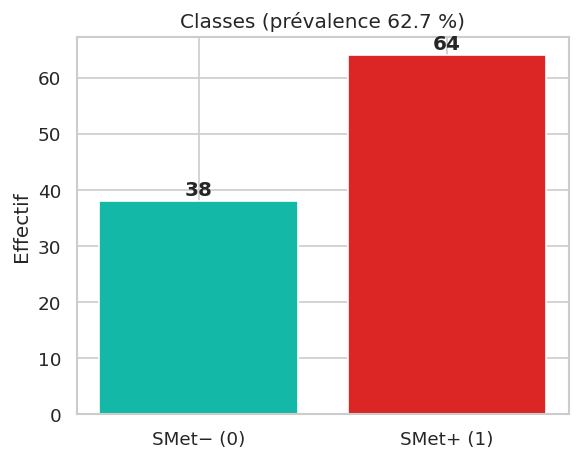

Déséquilibre modéré → StratifiedKFold obligatoire. Accuracy seule trompeuse.


In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["smet"].value_counts().sort_index()
ax.bar(["SMet− (0)", "SMet+ (1)"], counts.values, color=["#14B8A6", "#DC2626"])
ax.set_ylabel("Effectif")
ax.set_title(f"Classes (prévalence {prev*100:.1f} %)")
for i, v in enumerate(counts.values):
    ax.text(i, v + 1, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Déséquilibre modéré → StratifiedKFold obligatoire. Accuracy seule trompeuse.")


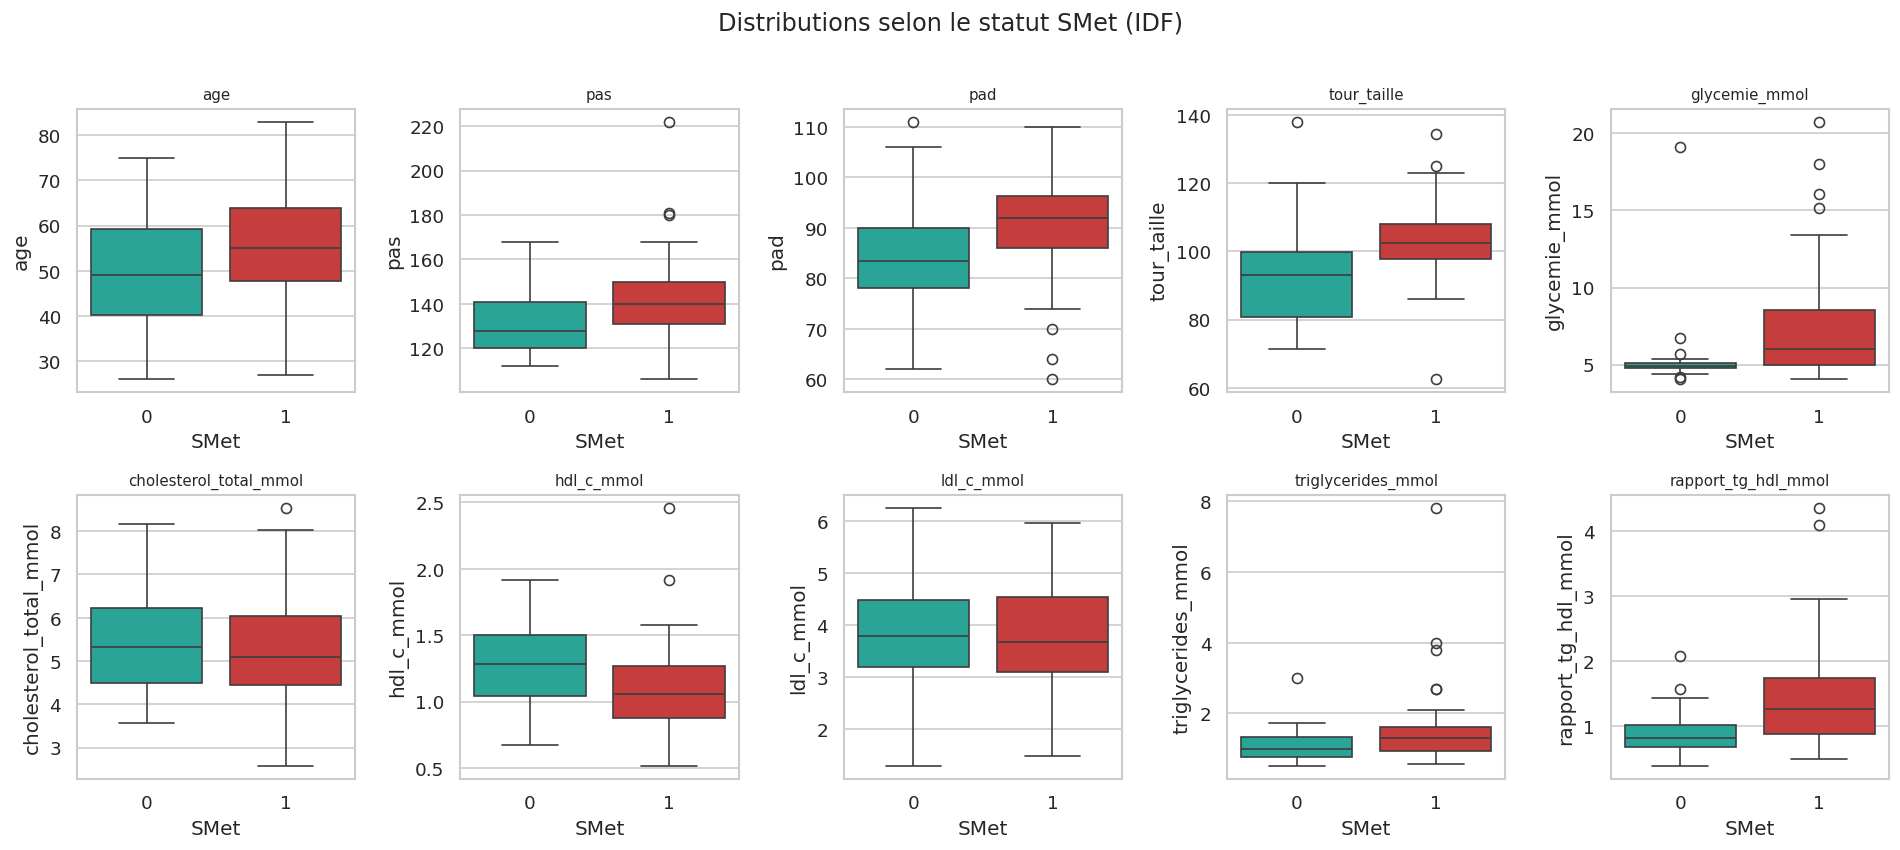

In [ ]:
num_cols = [
    "age", "pas", "pad", "tour_taille",
    "glycemie_mmol", "cholesterol_total_mmol", "hdl_c_mmol",
    "ldl_c_mmol", "triglycerides_mmol", "rapport_tg_hdl_mmol",
]
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x="smet", y=col, ax=axes[i], palette=["#14B8A6", "#DC2626"])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("SMet")
plt.suptitle("Distributions selon le statut SMet (IDF)", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_boxplots_by_smet.png", dpi=150, bbox_inches="tight")
plt.show()


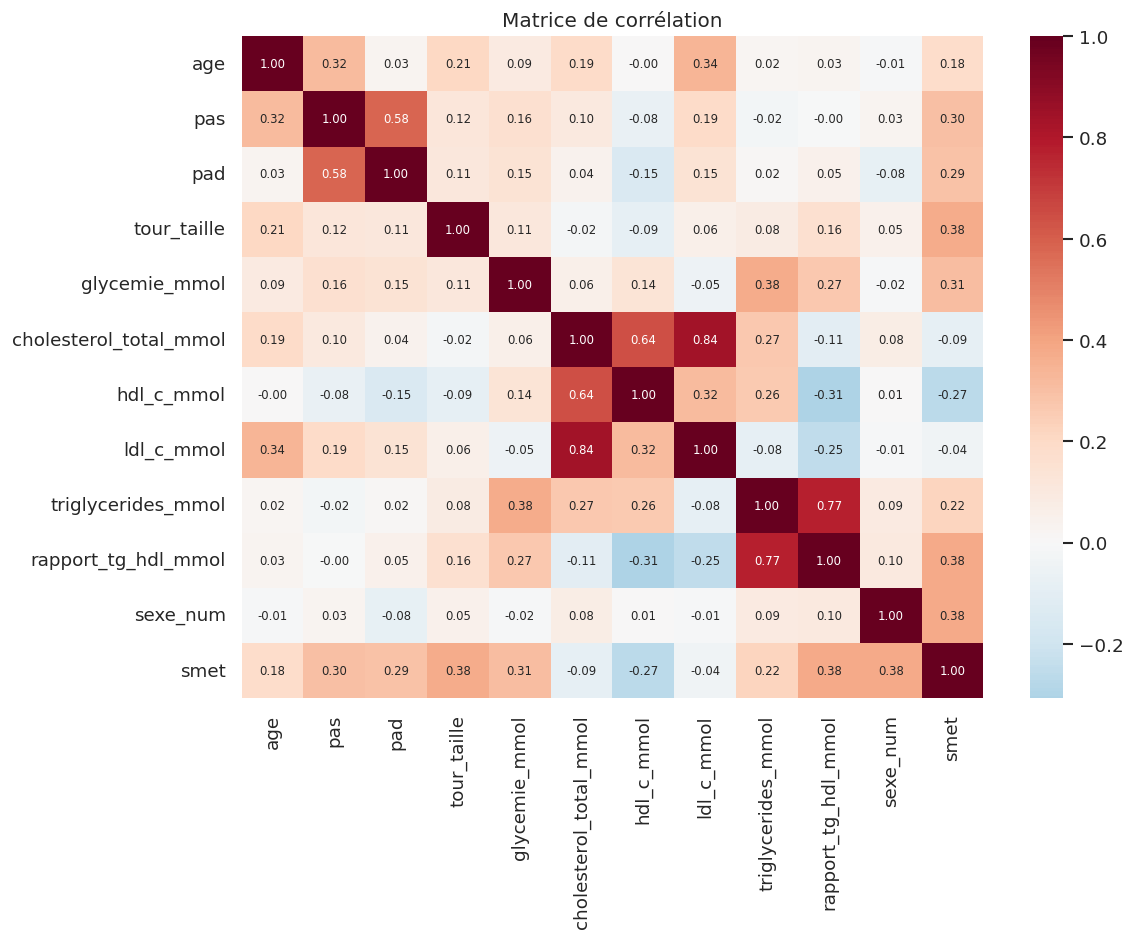

Corrélation TG/HDL-C vs SMet: 0.378


In [ ]:
corr_cols = num_cols + ["sexe_num", "smet"]
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, annot_kws={"size": 7})
ax.set_title("Matrice de corrélation")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Corrélation TG/HDL-C vs SMet:", round(corr.loc["rapport_tg_hdl_mmol", "smet"], 3))


## 3. Section biomarqueur — TG/HDL-C seul

Trois questions :
1. Le ratio **seul** porte-t-il un signal discriminant ?
2. Le score **clinique** porte-t-il déjà un signal ?
3. Le ratio **ajoute-t-il** de l'information au clinique ? ← **question centrale**


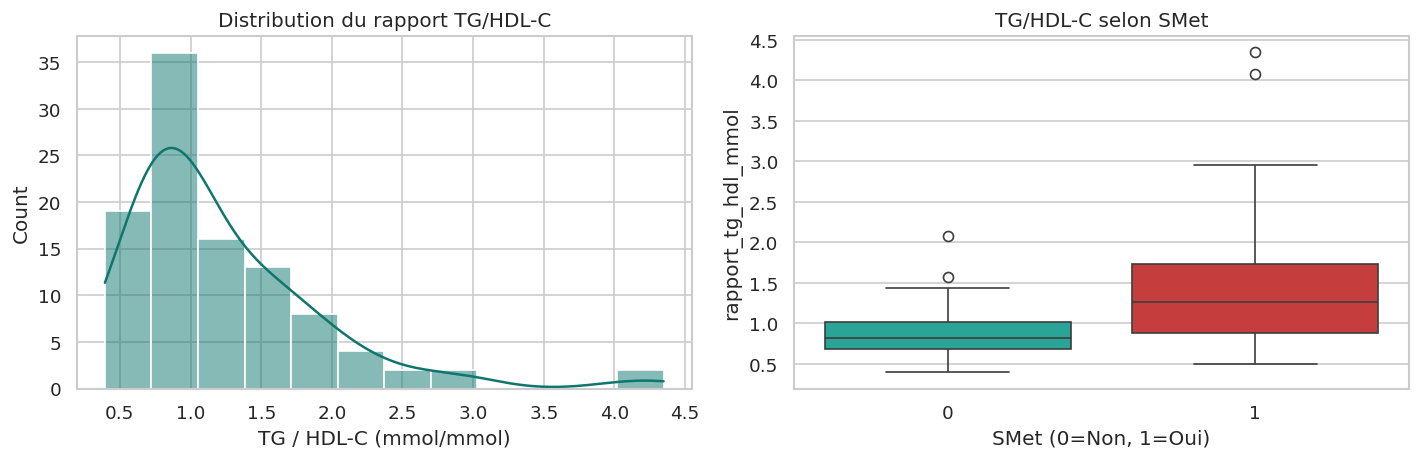

Moyenne TG/HDL — SMet−: 0.886
Moyenne TG/HDL — SMet+: 1.429


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["rapport_tg_hdl_mmol"], kde=True, ax=axes[0], color="#0F766E")
axes[0].set_title("Distribution du rapport TG/HDL-C")
axes[0].set_xlabel("TG / HDL-C (mmol/mmol)")
sns.boxplot(data=df, x="smet", y="rapport_tg_hdl_mmol", ax=axes[1],
            palette=["#14B8A6", "#DC2626"])
axes[1].set_title("TG/HDL-C selon SMet")
axes[1].set_xlabel("SMet (0=Non, 1=Oui)")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_tg_hdl_focus.png", dpi=150, bbox_inches="tight")
plt.show()
m0 = df.loc[df.smet == 0, "rapport_tg_hdl_mmol"].mean()
m1 = df.loc[df.smet == 1, "rapport_tg_hdl_mmol"].mean()
print(f"Moyenne TG/HDL — SMet−: {m0:.3f}")
print(f"Moyenne TG/HDL — SMet+: {m1:.3f}")


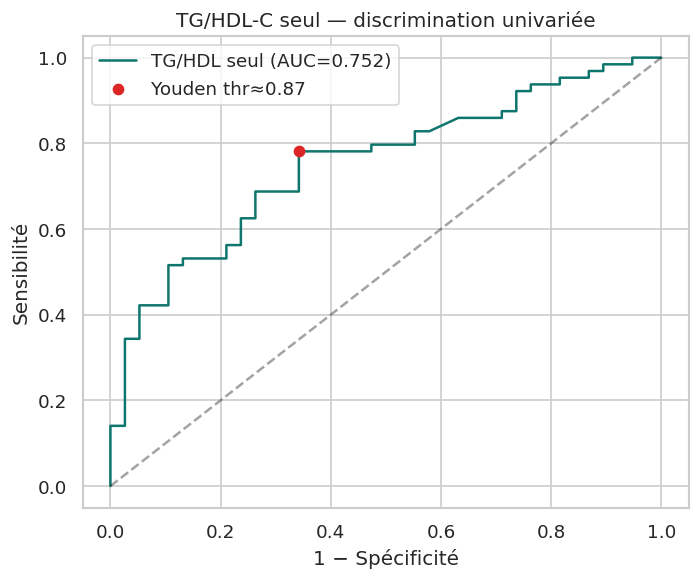

AUC TG/HDL seul = 0.752
Seuil Youden exploratoire ≈ 0.866 | Sens=0.781 | Spec=0.658
Ce seuil n'est PAS un seuil clinique validé.


In [ ]:
# ROC du biomarqueur seul (univarié)
y = df["smet"].values
score_uni = df["rapport_tg_hdl_mmol"].values
auc_uni = roc_auc_score(y, score_uni)
fpr_u, tpr_u, thr_u = roc_curve(y, score_uni)
# Youden exploratoire sur le ratio seul
j_u = tpr_u - fpr_u
k_u = int(np.argmax(j_u))
thr_youden_uni = thr_u[k_u]
pred_uni = (score_uni >= thr_youden_uni).astype(int)
sens_uni = recall_score(y, pred_uni, pos_label=1)
spec_uni = recall_score(y, pred_uni, pos_label=0)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_u, tpr_u, color="#0F766E", label=f"TG/HDL seul (AUC={auc_uni:.3f})")
ax.scatter(fpr_u[k_u], tpr_u[k_u], color="#DC2626", zorder=5,
           label=f"Youden thr≈{thr_youden_uni:.2f}")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("1 − Spécificité")
ax.set_ylabel("Sensibilité")
ax.set_title("TG/HDL-C seul — discrimination univariée")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "05b_tg_hdl_univariate_roc.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"AUC TG/HDL seul = {auc_uni:.3f}")
print(f"Seuil Youden exploratoire ≈ {thr_youden_uni:.3f} | Sens={sens_uni:.3f} | Spec={spec_uni:.3f}")
print("Ce seuil n'est PAS un seuil clinique validé.")


## ★ Analyse critique — TG/HDL-C seul peut-il soutenir une stratégie de dépistage simple ?

### Question que le jury posera (à anticiper)

> *« Pourquoi un modèle de machine learning si le rapport TG/HDL-C **seul** discrimine déjà le SMet ? »*

C'est une **bonne** question. Elle force à distinguer :

| Niveau | Rôle |
|--------|------|
| **M0 — TG/HDL-C seul** | Règle simple, un seuil, zéro ML — candidat « outil de terrain » |
| **M1 — Clinique** | Baseline sans labo |
| **M2 — Clinique + TG/HDL** | **Modèle principal** : valeur *incrémentale* du biomarqueur |
| **M3 — Clinique + lab** | Plafond exploratoire (circularité partielle) |

**Réponse honnête attendue :**
1. M0 teste si le biomarqueur **porte un signal** et s'il pourrait, *un jour*, ancrer une règle simple.
2. M2 teste si le ratio **ajoute** de l'information au-delà du profil clinique (question scientifique centrale).
3. Même si M0 a une AUC correcte, un modèle clinique+ratio peut intégrer âge, sexe, TA, tour de taille — utiles en soins primaires.
4. **Aucun** de ces modèles n'est validé pour un déploiement clinique actuel (n=102, monocentrique).

---

### Scénarios formels

| Scénario | Variables | Rôle |
|----------|-----------|------|
| **M0** | `rapport_tg_hdl_mmol` | Biomarqueur seul — dépistage ultra-simple ? |
| **M1** | âge, sexe, PAS, PAD, tour de taille | Baseline clinique |
| **M2** | M1 + TG/HDL-C | Analyse principale |
| **M3** | M1 + gly, CT, HDL, LDL, TG, ratio | Référence exploratoire |


In [ ]:
# ============================================================
# M0 — TG/HDL-C seul : discrimination, seuil, IC, VPP/VPN
# ============================================================
y_arr = df["smet"].values
score_m0 = df["rapport_tg_hdl_mmol"].values

auc_m0 = roc_auc_score(y_arr, score_m0)

rng = np.random.default_rng(RANDOM_STATE)
n_boot = 2000
auc_boot = []
for _ in range(n_boot):
    idx = rng.integers(0, len(y_arr), len(y_arr))
    if len(np.unique(y_arr[idx])) < 2:
        continue
    auc_boot.append(roc_auc_score(y_arr[idx], score_m0[idx]))
auc_boot = np.array(auc_boot)
ci_lo_m0, ci_hi_m0 = np.percentile(auc_boot, [2.5, 97.5])

fpr0, tpr0, thr0 = roc_curve(y_arr, score_m0)
j0 = tpr0 - fpr0
k0 = int(np.argmax(j0))
thr_youden_m0 = float(thr0[k0])
pred_m0 = (score_m0 >= thr_youden_m0).astype(int)

tn, fp, fn, tp = confusion_matrix(y_arr, pred_m0).ravel()
sens_m0 = tp / (tp + fn) if (tp + fn) else np.nan
spec_m0 = tn / (tn + fp) if (tn + fp) else np.nan
ppv_m0 = tp / (tp + fp) if (tp + fp) else np.nan
npv_m0 = tn / (tn + fn) if (tn + fn) else np.nan
prev = float(y_arr.mean())

print("=" * 60)
print("M0 — TG/HDL-C SEUL (stratégie de dépistage ultra-simple ?)")
print("=" * 60)
print(f"AUC              = {auc_m0:.3f}")
print(f"IC 95 % bootstrap = [{ci_lo_m0:.3f}, {ci_hi_m0:.3f}]  (n_boot={len(auc_boot)})")
print(f"Seuil Youden*    ≈ {thr_youden_m0:.3f}   (*exploratoire, PAS clinique)")
print(f"Sensibilité      = {sens_m0:.3f}")
print(f"Spécificité      = {spec_m0:.3f}")
print(f"VPP              = {ppv_m0:.3f}   ← lié à la prévalence hospitalière {prev*100:.1f} %")
print(f"VPN              = {npv_m0:.3f}   ← changerait en population générale")
print()
print("Avertissement VPP/VPN :")
print("  Dans une population de soins primaires (prévalence SMet plus basse),")
print("  la VPP baisserait et la VPN monterait. Ne pas extrapoler ces chiffres.")


M0 — TG/HDL-C SEUL (stratégie de dépistage ultra-simple ?)
AUC              = 0.752
IC 95 % bootstrap = [0.656, 0.841]  (n_boot=2000)
Seuil Youden*    ≈ 0.866   (*exploratoire, PAS clinique)
Sensibilité      = 0.781
Spécificité      = 0.658
VPP              = 0.794   ← lié à la prévalence hospitalière 62.7 %
VPN              = 0.641   ← changerait en population générale

Avertissement VPP/VPN :
  Dans une population de soins primaires (prévalence SMet plus basse),
  la VPP baisserait et la VPN monterait. Ne pas extrapoler ces chiffres.


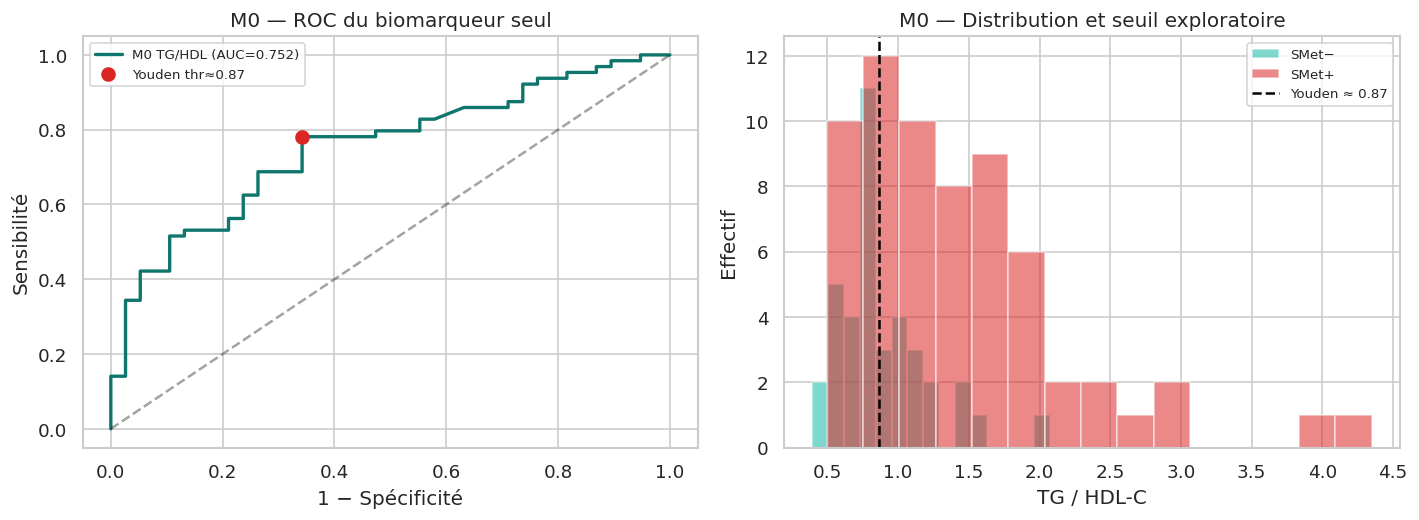

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(fpr0, tpr0, color="#0F766E", lw=2, label=f"M0 TG/HDL (AUC={auc_m0:.3f})")
axes[0].scatter(fpr0[k0], tpr0[k0], c="#DC2626", s=60, zorder=5,
                label=f"Youden thr≈{thr_youden_m0:.2f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("1 − Spécificité")
axes[0].set_ylabel("Sensibilité")
axes[0].set_title("M0 — ROC du biomarqueur seul")
axes[0].legend(fontsize=8)

axes[1].hist(score_m0[y_arr == 0], bins=15, alpha=0.55, color="#14B8A6", label="SMet−")
axes[1].hist(score_m0[y_arr == 1], bins=15, alpha=0.55, color="#DC2626", label="SMet+")
axes[1].axvline(thr_youden_m0, color="black", ls="--", lw=1.5, label=f"Youden ≈ {thr_youden_m0:.2f}")
axes[1].set_xlabel("TG / HDL-C")
axes[1].set_ylabel("Effectif")
axes[1].set_title("M0 — Distribution et seuil exploratoire")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "11_M0_tg_hdl_screening.png", dpi=150, bbox_inches="tight")
plt.show()


### Comparaison tête-à-tête : M0 vs M1 vs M2 vs M3

Même esprit de protocole : AUC + IC bootstrap ; sensibilité / spécificité au seuil **Youden propre à chaque score** (plus équitable qu'un seul seuil 0,5).

> Le seuil Youden est **optimisé sur cette cohorte** → performance un peu optimiste. Il ne doit pas être présenté comme seuil clinique.


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, recall_score

RANDOM_STATE = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
y = df["smet"]

FEATURES_A = ["age", "sexe_num", "pas", "pad", "tour_taille"]
FEATURES_B = FEATURES_A + ["rapport_tg_hdl_mmol"]
FEATURES_C = FEATURES_A + [
    "glycemie_mmol", "cholesterol_total_mmol", "hdl_c_mmol",
    "ldl_c_mmol", "triglycerides_mmol", "rapport_tg_hdl_mmol",
]

def make_gb():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingClassifier(
            n_estimators=100, max_depth=3, random_state=RANDOM_STATE
        )),
    ])

def make_lr():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ])

def make_rf():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            n_estimators=200, max_depth=5, random_state=RANDOM_STATE
        )),
    ])

print("OK — make_gb, FEATURES_A/B/C, cv, y définis")
print("Colonnes OK ?", all(c in df.columns for c in FEATURES_C))

OK — make_gb, FEATURES_A/B/C, cv, y définis
Colonnes OK ? True


In [ ]:
def oof_proba(feats, factory=make_gb):
    pipe = factory()
    return cross_val_predict(pipe, df[feats], y, cv=cv, method="predict_proba")[:, 1]

def metrics_from_scores(name, scores, y_true):
    auc = roc_auc_score(y_true, scores)
    boots = []
    for _ in range(1000):
        idx = rng.integers(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue
        boots.append(roc_auc_score(y_true[idx], scores[idx]))
    boots = np.array(boots)
    lo, hi = np.percentile(boots, [2.5, 97.5])

    fpr, tpr, thr = roc_curve(y_true, scores)
    k = int(np.argmax(tpr - fpr))
    thr_j = float(thr[k])
    pred_j = (scores >= thr_j).astype(int)
    sens_j = recall_score(y_true, pred_j, pos_label=1)
    spec_j = recall_score(y_true, pred_j, pos_label=0)

    if scores.min() >= 0 and scores.max() <= 1.0 + 1e-6:
        pred05 = (scores >= 0.5).astype(int)
        sens05 = round(recall_score(y_true, pred05, pos_label=1), 3)
        spec05 = round(recall_score(y_true, pred05, pos_label=0), 3)
    else:
        sens05, spec05 = "—", "—"

    return {
        "Scénario": name,
        "AUC": round(auc, 3),
        "IC95_lo": round(lo, 3),
        "IC95_hi": round(hi, 3),
        "Thr_Youden": round(thr_j, 3),
        "Sens_Youden": round(sens_j, 3),
        "Spec_Youden": round(spec_j, 3),
        "Sens_0.5": sens05,
        "Spec_0.5": spec05,
        "scores": scores,
    }

scores_m1 = oof_proba(FEATURES_A, make_gb)
scores_m2 = oof_proba(FEATURES_B, make_gb)
scores_m3 = oof_proba(FEATURES_C, make_gb)

rows = [
    metrics_from_scores("M0 — TG/HDL seul", score_m0, y_arr),
    metrics_from_scores("M1 — Clinique", scores_m1, y_arr),
    metrics_from_scores("M2 — Clinique+TG/HDL", scores_m2, y_arr),
    metrics_from_scores("M3 — Clinique+Lab (expl.)", scores_m3, y_arr),
]

cmp = pd.DataFrame([{k: v for k, v in r.items() if k != "scores"} for r in rows])
print("Comparaison M0 / M1 / M2 / M3")
print("(Youden = seuil exploratoire optimisé sur CETTE cohorte — légèrement optimiste)")
display(cmp)

a0 = rows[0]["AUC"]
a1 = rows[1]["AUC"]
a2 = rows[2]["AUC"]
print(f"\nΔ AUC M2 − M1 (valeur ajoutée TG/HDL au clinique) = {a2 - a1:+.3f}")
print(f"Δ AUC M2 − M0 (clinique+ratio vs ratio seul)     = {a2 - a0:+.3f}")
print(f"Δ AUC M1 − M0 (clinique vs ratio seul)           = {a1 - a0:+.3f}")


Comparaison M0 / M1 / M2 / M3
(Youden = seuil exploratoire optimisé sur CETTE cohorte — légèrement optimiste)


,Scénario,AUC,IC95_lo,IC95_hi,Thr_Youden,Sens_Youden,Spec_Youden,Sens_0.5,Spec_0.5
0,M0 — TG/HDL seul,0.752,0.645,0.843,0.866,0.781,0.658,—,—
1,M1 — Clinique,0.779,0.673,0.880,0.802,0.781,0.763,0.875,0.632
2,M2 — Clinique+TG/HDL,0.817,0.723,0.891,0.949,0.656,0.895,0.797,0.605
3,M3 — Clinique+Lab (expl.),0.871,0.775,0.945,0.590,0.938,0.763,0.984,0.711



Δ AUC M2 − M1 (valeur ajoutée TG/HDL au clinique) = +0.038
Δ AUC M2 − M0 (clinique+ratio vs ratio seul)     = +0.065
Δ AUC M1 − M0 (clinique vs ratio seul)           = +0.027


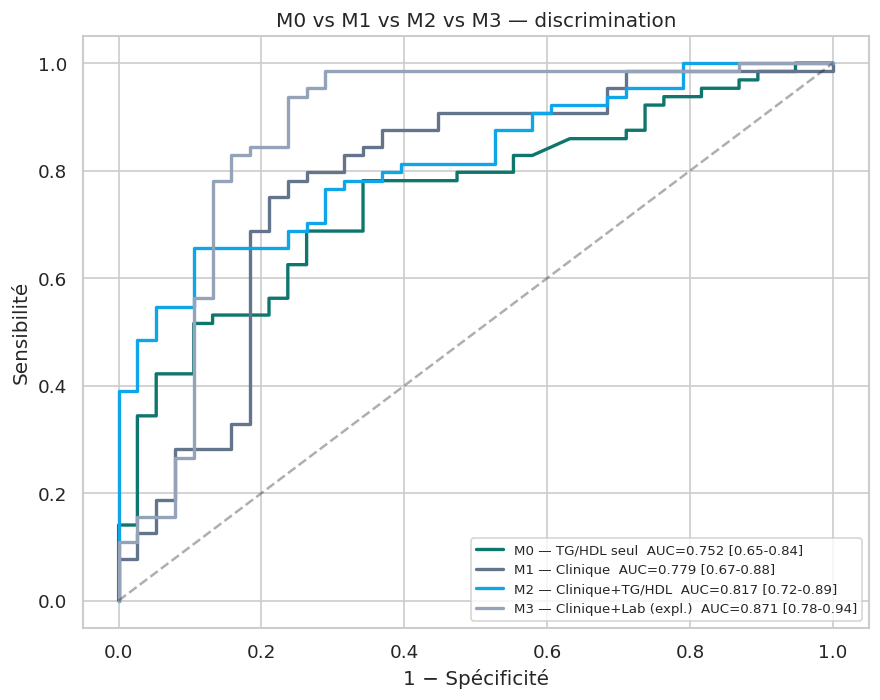

Export → /content/figures/metrics_M0_M1_M2_M3.csv


In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 6))
colors = ["#0F766E", "#64748B", "#0EA5E9", "#94A3B8"]
for r, c in zip(rows, colors):
    fpr, tpr, _ = roc_curve(y_arr, r["scores"])
    ax.plot(fpr, tpr, color=c, lw=2,
            label=f"{r['Scénario']}  AUC={r['AUC']:.3f} [{r['IC95_lo']:.2f}-{r['IC95_hi']:.2f}]")
ax.plot([0, 1], [0, 1], "k--", alpha=0.35)
ax.set_xlabel("1 − Spécificité")
ax.set_ylabel("Sensibilité")
ax.set_title("M0 vs M1 vs M2 vs M3 — discrimination")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "12_M0_M1_M2_M3_roc.png", dpi=150, bbox_inches="tight")
plt.show()

cmp.to_csv(FIG_DIR / "metrics_M0_M1_M2_M3.csv", index=False)
print("Export →", FIG_DIR / "metrics_M0_M1_M2_M3.csv")


### Réponse structurée pour le jury

**1. Le TG/HDL-C seul (M0) porte-t-il un signal ?**  
Oui — AUC univariée avec IC 95 % bootstrap. Un seuil Youden *exploratoire* donne une paire sens/spéc **sur cette cohorte uniquement**.

**2. Suffit-il comme stratégie de dépistage ?**  
Pas sur la base de n=102 monocentrique. VPP/VPN sont influencés par la prévalence hospitalière (62,7 %). En population générale, la VPP chuterait. **Aucun seuil clinique n'est proposé ici.**

**3. Alors pourquoi M2 (clinique + TG/HDL) ?**  
Parce que la question n'est pas seulement « le ratio seul marche-t-il ? », mais :
- que vaut un **score clinique** quand le labo est absent (M1) ?
- le ratio **améliore-t-il** ce score quand un bilan lipidique minimal est disponible (M2) ?

Si Δ(M2−M1) > 0 de façon raisonnablement stable, le biomarqueur a une **valeur incrémentale** — argument pour l'inclure dans un *futur* outil, pas pour le déployer demain.

**4. Pourquoi ne pas s'arrêter à « si TG/HDL > x alors à risque » ?**  
On le *teste* (M0). Mais âge, sexe, tour de taille et TA sont des informations de terrain gratuites. Les combiner avec le ratio (M2) se rapproche d'un **profil de risque**, pas d'un seul cut-off.

**5. Formulation autorisée :**
> M0 montre que le biomarqueur seul discrimine partiellement le SMet. M2 montre qu'il apporte une information supplémentaire au profil clinique. Ensemble, ces résultats soutiennent une **preuve de concept** pour un outil de dépistage simple — **sous réserve** de validation externe et de recalibrage du seuil.


> **Alias :** dans le reste du notebook, bras **A = M1**, **B = M2**, **C = M3**.  
> La section ci-dessus ajoute explicitement **M0 (TG/HDL seul)** pour la question de dépistage simple.


## 4. Prétraitement et définitions des bras

### Décision features — pression pulsée
`pression_pulsee = PAS − PAD` est une **combinaison linéaire** de PAS et PAD.  
**Décision :** retirer `pression_pulsee` des modèles pour limiter la redondance.  
PAS et PAD restent (composantes HTA du syndrome métabolique / profil clinique).

| Bras | Features | Rôle |
|------|----------|------|
| **A** | âge, sexe, PAS, PAD, tour de taille | Clinique seul (sans labo) |
| **B** | A + **rapport_tg_hdl_mmol** | **Analyse principale** — valeur ajoutée du biomarqueur |
| **C** | A + gly, CT, HDL, LDL, TG, ratio | Référence exploratoire — **circularité partielle** |


In [ ]:
FEATURES_A = ["age", "sexe_num", "pas", "pad", "tour_taille"]
FEATURES_B = FEATURES_A + ["rapport_tg_hdl_mmol"]
FEATURES_C = FEATURES_A + [
    "glycemie_mmol", "cholesterol_total_mmol", "hdl_c_mmol",
    "ldl_c_mmol", "triglycerides_mmol", "rapport_tg_hdl_mmol",
]
y = df["smet"]
print("A:", FEATURES_A)
print("B:", FEATURES_B)
print("C:", FEATURES_C)
print("y:", y.value_counts().to_dict())


A: ['age', 'sexe_num', 'pas', 'pad', 'tour_taille']
B: ['age', 'sexe_num', 'pas', 'pad', 'tour_taille', 'rapport_tg_hdl_mmol']
C: ['age', 'sexe_num', 'pas', 'pad', 'tour_taille', 'glycemie_mmol', 'cholesterol_total_mmol', 'hdl_c_mmol', 'ldl_c_mmol', 'triglycerides_mmol', 'rapport_tg_hdl_mmol']
y: {1: 64, 0: 38}


## 5. Modélisation — discrimination A / B / C

- Validation : **Stratified 5-fold CV**  
- Prédictions **out-of-fold** (pas de fuite)  
- Scaler **dans** le pipeline  
- Métriques : AUC, PR-AUC, sens/spéc @0,5, F1, accuracy (secondaire), Brier


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def make_gb():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingClassifier(
            n_estimators=100, max_depth=3, random_state=RANDOM_STATE
        )),
    ])

def make_lr():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ])

def make_rf():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            n_estimators=200, max_depth=5, random_state=RANDOM_STATE
        )),
    ])

def evaluate(name, feats, factory=make_gb):
    X = df[feats]
    pipe = factory()
    aucs = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
    y_prob = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        "name": name,
        "auc_mean": float(aucs.mean()),
        "auc_std": float(aucs.std()),
        "aucs": aucs,
        "pr_auc": float(average_precision_score(y, y_prob)),
        "sensitivity": float(recall_score(y, y_pred, pos_label=1)),
        "specificity": float(recall_score(y, y_pred, pos_label=0)),
        "f1": float(f1_score(y, y_pred)),
        "accuracy": float(accuracy_score(y, y_pred)),
        "brier": float(brier_score_loss(y, y_prob)),
        "y_prob": y_prob,
        "y_pred": y_pred,
    }

results = []
for name, feats in [
    ("A — Clinical only", FEATURES_A),
    ("B — Clinical + TG/HDL", FEATURES_B),
    ("C — Clinical + Lab", FEATURES_C),
]:
    r = evaluate(name, feats, make_gb)
    results.append(r)
    print(f"{r['name']:28s} AUC={r['auc_mean']:.3f}±{r['auc_std']:.3f}  "
          f"PR-AUC={r['pr_auc']:.3f}  Sens={r['sensitivity']:.3f}  "
          f"Spec={r['specificity']:.3f}  Brier={r['brier']:.3f}")


A — Clinical only            AUC=0.790±0.057  PR-AUC=0.825  Sens=0.875  Spec=0.632  Brier=0.189
B — Clinical + TG/HDL        AUC=0.836±0.064  PR-AUC=0.899  Sens=0.797  Spec=0.605  Brier=0.219
C — Clinical + Lab           AUC=0.932±0.064  PR-AUC=0.882  Sens=0.984  Spec=0.711  Brier=0.111


In [ ]:
summary = pd.DataFrame([{
    "Bras": r["name"],
    "AUC_CV5": round(r["auc_mean"], 3),
    "AUC_std": round(r["auc_std"], 3),
    "PR_AUC": round(r["pr_auc"], 3),
    "Sens@0.5": round(r["sensitivity"], 3),
    "Spec@0.5": round(r["specificity"], 3),
    "F1": round(r["f1"], 3),
    "Brier": round(r["brier"], 3),
    "Accuracy": round(r["accuracy"], 3),
} for r in results])
display(summary)
delta_ba = results[1]["auc_mean"] - results[0]["auc_mean"]
delta_cb = results[2]["auc_mean"] - results[1]["auc_mean"]
print(f"\nΔAUC (B − A) = {delta_ba:+.3f}   ← gain du biomarqueur au-delà du clinique")
print(f"ΔAUC (C − B) = {delta_cb:+.3f}   ← gain labo supplémentaire (circularité partielle)")


,Bras,AUC_CV5,AUC_std,PR_AUC,Sens@0.5,Spec@0.5,F1,Brier,Accuracy
0,A — Clinical only,0.790,0.057,0.825,0.875,0.632,0.836,0.189,0.784
1,B — Clinical + TG/HDL,0.836,0.064,0.899,0.797,0.605,0.785,0.219,0.725
2,C — Clinical + Lab,0.932,0.064,0.882,0.984,0.711,0.913,0.111,0.882



ΔAUC (B − A) = +0.046   ← gain du biomarqueur au-delà du clinique
ΔAUC (C − B) = +0.096   ← gain labo supplémentaire (circularité partielle)


### 5.1 Bootstrap du ΔAUC (B − A) — incertitude sur n=102

Avec un petit échantillon, un gain de ~0,06 peut être fragile.  
On estime un **intervalle de confiance empirique** du ΔAUC par bootstrap des prédictions OOF.


In [ ]:
rng = np.random.default_rng(RANDOM_STATE)
prob_a = results[0]["y_prob"]
prob_b = results[1]["y_prob"]
y_arr = y.values if hasattr(y, "values") else np.asarray(y)
n = len(y_arr)
n_boot = 1000
deltas = []
for _ in range(n_boot):
    idx = rng.integers(0, n, n)
    if len(np.unique(y_arr[idx])) < 2:
        continue
    d = roc_auc_score(y_arr[idx], prob_b[idx]) - roc_auc_score(y_arr[idx], prob_a[idx])
    deltas.append(d)
deltas = np.array(deltas)
ci_lo, ci_hi = np.percentile(deltas, [2.5, 97.5])
print(f"ΔAUC observé (B−A) = {delta_ba:+.3f}")
print(f"Bootstrap 95% IC ≈ [{ci_lo:+.3f}, {ci_hi:+.3f}]  (n_boot={len(deltas)})")
print("Interprétation prudente: si l'IC chevauche 0, le gain n'est pas stable sur n=102.")
print("Si l'IC est majoritairement positif, le signal est encourageant mais reste monocentrique.")


ΔAUC observé (B−A) = +0.046
Bootstrap 95% IC ≈ [-0.044, +0.119]  (n_boot=1000)
Interprétation prudente: si l'IC chevauche 0, le gain n'est pas stable sur n=102.
Si l'IC est majoritairement positif, le signal est encourageant mais reste monocentrique.


### 5.2 Courbes ROC


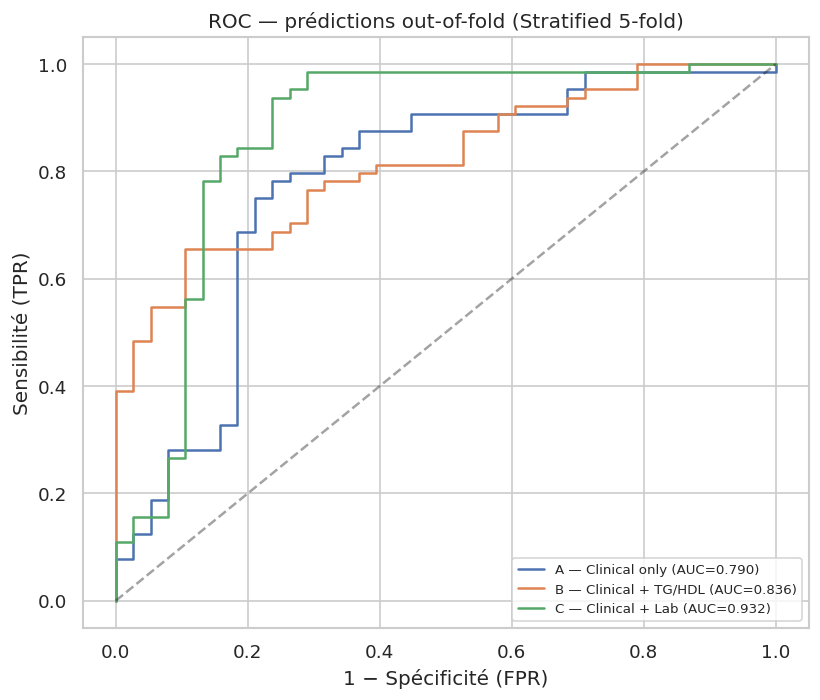

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
for r in results:
    fpr, tpr, _ = roc_curve(y, r["y_prob"])
    ax.plot(fpr, tpr, label=f"{r['name']} (AUC={r['auc_mean']:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("1 − Spécificité (FPR)")
ax.set_ylabel("Sensibilité (TPR)")
ax.set_title("ROC — prédictions out-of-fold (Stratified 5-fold)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_auc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.3 Matrices de confusion (seuil algorithmique 0,5)


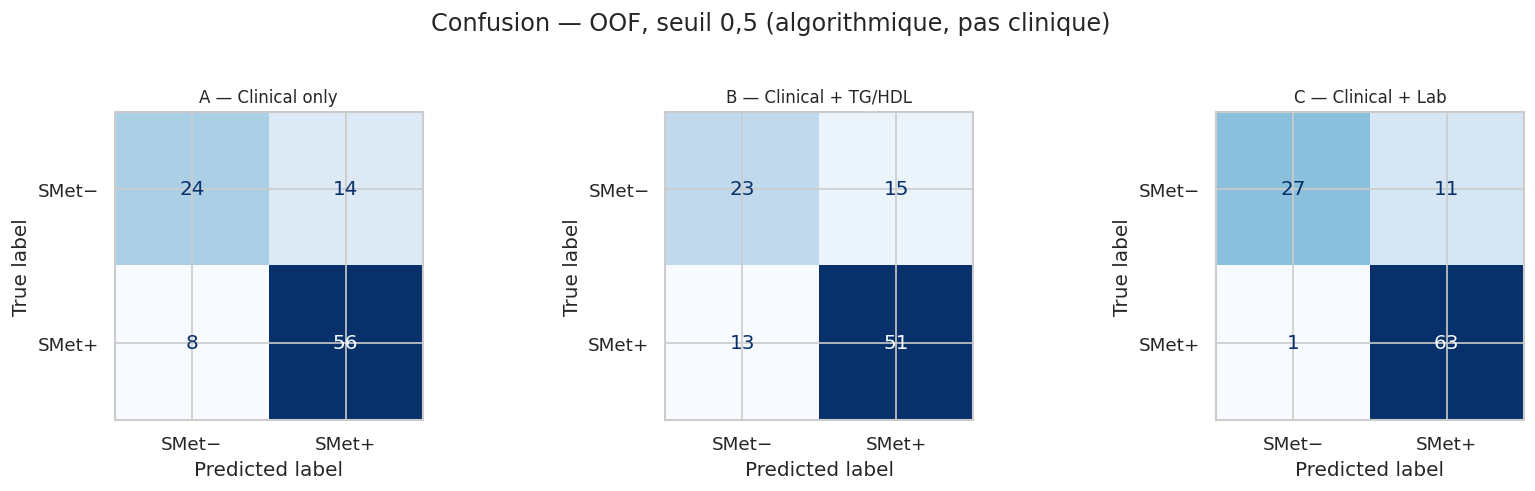

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, r in zip(axes, results):
    cm = confusion_matrix(y, r["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["SMet−", "SMet+"]).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(r["name"], fontsize=10)
plt.suptitle("Confusion — OOF, seuil 0,5 (algorithmique, pas clinique)", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "08_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.4 Seuil de dépistage — exploration Youden (bras B)

- **0,5** = seuil logiciel conventionnel  
- **Youden** = max(sens + spéc − 1) sur la courbe ROC OOF → **exploratoire**  
- Un vrai seuil de dépistage exige cohorte indépendante + objectif (priorité sensibilité vs spécificité)


In [ ]:
prob_b = results[1]["y_prob"]
fpr, tpr, thr = roc_curve(y, prob_b)
j = tpr - fpr
k = int(np.argmax(j))
thr_youden = thr[k]
pred_y = (prob_b >= thr_youden).astype(int)
sens_y = recall_score(y, pred_y, pos_label=1)
spec_y = recall_score(y, pred_y, pos_label=0)
print(f"Seuil Youden exploratoire (bras B) ≈ {thr_youden:.3f}")
print(f"  Sensibilité = {sens_y:.3f} | Spécificité = {spec_y:.3f}")
print(f"Comparaison seuil 0,5 → Sens={results[1]['sensitivity']:.3f} Spec={results[1]['specificity']:.3f}")
print("Pour un outil de screening, on privilégie souvent la sensibilité —")
print("mais le seuil final n'est PAS fixé ici.")


Seuil Youden exploratoire (bras B) ≈ 0.949
  Sensibilité = 0.656 | Spécificité = 0.895
Comparaison seuil 0,5 → Sens=0.797 Spec=0.605
Pour un outil de screening, on privilégie souvent la sensibilité —
mais le seuil final n'est PAS fixé ici.


### 5.5 Calibration (bras B)

**Discrimination** = séparer SMet+ / SMet− (AUC).  
**Calibration** = les probabilités prédites correspondent-elles aux fréquences observées ?  
Les deux comptent pour un futur outil de dépistage.


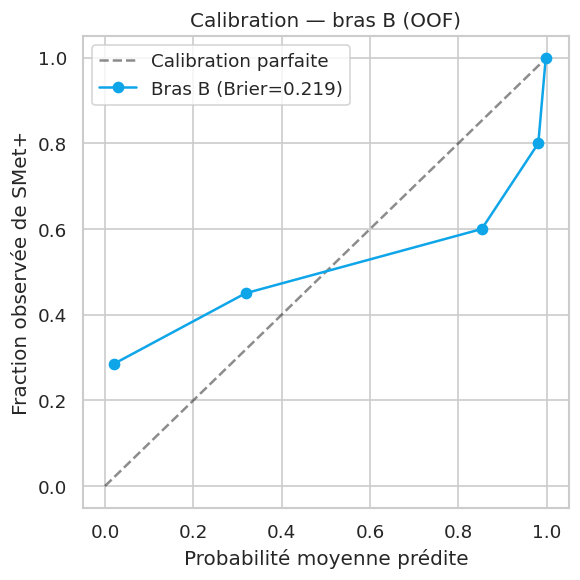

Brier score (plus bas = mieux). n=102 → calibration approximative (peu de bins).


In [ ]:
frac_pos, mean_pred = calibration_curve(y, prob_b, n_bins=5, strategy="quantile")
brier_b = results[1]["brier"]
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Calibration parfaite")
ax.plot(mean_pred, frac_pos, "o-", color="#0EA5E9", label=f"Bras B (Brier={brier_b:.3f})")
ax.set_xlabel("Probabilité moyenne prédite")
ax.set_ylabel("Fraction observée de SMet+")
ax.set_title("Calibration — bras B (OOF)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "09_calibration_B.png", dpi=150, bbox_inches="tight")
plt.show()
print("Brier score (plus bas = mieux). n=102 → calibration approximative (peu de bins).")


### 5.6 Comparaison d'algorithmes sur le bras B (analyse principale)


In [ ]:
algo_rows = []
algo_probs = {}
for label, factory in [
    ("Logistic Regression", make_lr),
    ("Random Forest", make_rf),
    ("Gradient Boosting", make_gb),
]:
    r = evaluate(label, FEATURES_B, factory)
    algo_rows.append({
        "Algo": label,
        "AUC": round(r["auc_mean"], 3),
        "PR_AUC": round(r["pr_auc"], 3),
        "Sens@0.5": round(r["sensitivity"], 3),
        "Spec@0.5": round(r["specificity"], 3),
        "Brier": round(r["brier"], 3),
    })
    algo_probs[label] = r["y_prob"]
    print(f"{label:22s} AUC={r['auc_mean']:.3f}  Brier={r['brier']:.3f}")
algo_df = pd.DataFrame(algo_rows)
display(algo_df)
print("La régression logistique est la baseline interprétable.")
print("Le modèle retenu pour la discussion doit allier performance, stabilité et lisibilité.")


Logistic Regression    AUC=0.891  Brier=0.141
Random Forest          AUC=0.873  Brier=0.150
Gradient Boosting      AUC=0.836  Brier=0.219


,Algo,AUC,PR_AUC,Sens@0.5,Spec@0.5,Brier
0,Logistic Regression,0.891,0.917,0.875,0.684,0.141
1,Random Forest,0.873,0.916,0.844,0.605,0.150
2,Gradient Boosting,0.836,0.899,0.797,0.605,0.219


La régression logistique est la baseline interprétable.
Le modèle retenu pour la discussion doit allier performance, stabilité et lisibilité.


## 6. Interprétabilité (pas de causalité)

### 6.1 Coefficients — Logistic Regression (bras B)


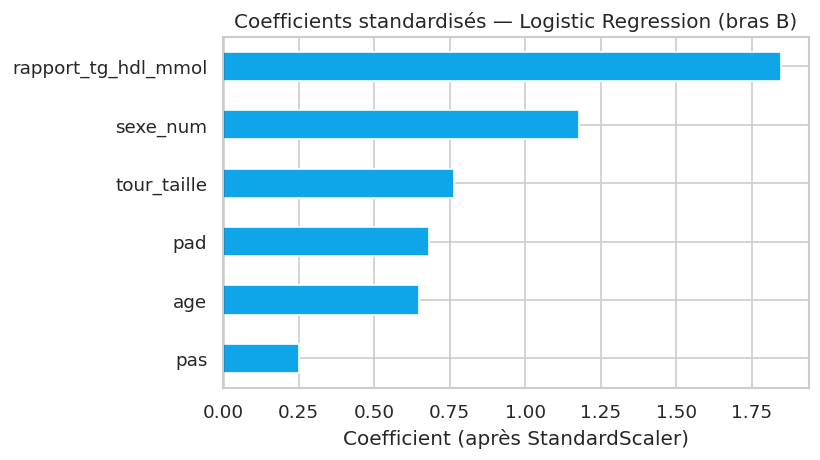

pas                    0.250
age                    0.647
pad                    0.682
tour_taille            0.763
sexe_num               1.179
rapport_tg_hdl_mmol    1.847
dtype: float64

Un coefficient positif associé au ratio indique une association avec P(SMet+),
toutes choses égales par ailleurs *dans le modèle* — pas une relation causale.


In [ ]:
pipe_lr = make_lr()
pipe_lr.fit(df[FEATURES_B], y)
coefs = pd.Series(
    pipe_lr.named_steps["model"].coef_.ravel(),
    index=FEATURES_B
).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
coefs.plot(kind="barh", ax=ax, color="#0EA5E9")
ax.axvline(0, color="k", lw=0.8)
ax.set_title("Coefficients standardisés — Logistic Regression (bras B)")
ax.set_xlabel("Coefficient (après StandardScaler)")
plt.tight_layout()
plt.savefig(FIG_DIR / "10_lr_coefficients_B.png", dpi=150, bbox_inches="tight")
plt.show()
print(coefs.round(3))
print("\nUn coefficient positif associé au ratio indique une association avec P(SMet+),")
print("toutes choses égales par ailleurs *dans le modèle* — pas une relation causale.")


### 6.2 Permutation importance (Gradient Boosting, bras B)


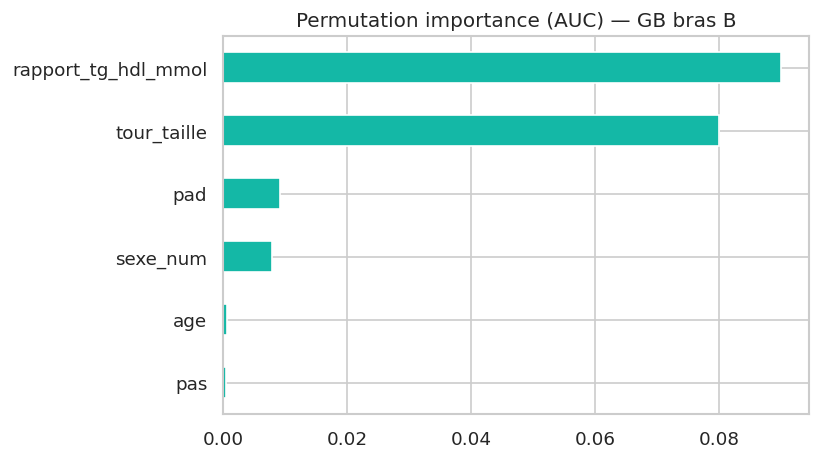

pas                    0.0005
age                    0.0006
sexe_num               0.0078
pad                    0.0092
tour_taille            0.0800
rapport_tg_hdl_mmol    0.0900
dtype: float64


In [ ]:
pipe_gb = make_gb()
pipe_gb.fit(df[FEATURES_B], y)
perm = permutation_importance(
    pipe_gb, df[FEATURES_B], y, n_repeats=30,
    scoring="roc_auc", random_state=RANDOM_STATE
)
imp = pd.Series(perm.importances_mean, index=FEATURES_B).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
imp.plot(kind="barh", ax=ax, color="#14B8A6")
ax.set_title("Permutation importance (AUC) — GB bras B")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print(imp.round(4))


## 7. Circularité — schéma conceptuel

Le SMet (IDF) est **défini** à partir de : tour de taille, TG, HDL, glycémie, pression artérielle.

```text
                    ┌─ Tour de taille ────────────┐
                    ├─ Pression artérielle ───────┤
 Critères IDF  ──►  ├─ Glycémie ──────────────────┼──►  Label SMet
                    ├─ Triglycérides ─────────────┤
                    └─ HDL-C ─────────────────────┘
                              │
                              ▼
                         TG / HDL-C   ← biomarqueur dérivé (2 des 5 critères)
```

- **Bras A** : variables cliniques sans labo → pas de circularité labo  
- **Bras B** : ajoute un ratio dérivé de TG et HDL → intérêt = *valeur ajoutée* au clinique  
- **Bras C** : inclut gly, TG, HDL… → performance en partie **attendue** (variables proches de la définition) → plafond de référence, **pas** preuve d'innovation indépendante


## 8. Analyse des erreurs (bras B, seuil 0,5)

Les erreurs OOF illustrent des **profils intermédiaires** et les limites de n=102 —  
elles ne « contredisent » pas le diagnostic clinique IDF.


In [ ]:
df_err = df[["code_patient", "age", "sexe", "tour_taille", "pas", "pad",
             "rapport_tg_hdl_mmol", "smet"]].copy()
df_err["proba_B"] = results[1]["y_prob"]
df_err["pred_B"] = results[1]["y_pred"]

fn = df_err[(df_err.smet == 1) & (df_err.pred_B == 0)].sort_values("proba_B")
fp = df_err[(df_err.smet == 0) & (df_err.pred_B == 1)].sort_values("proba_B", ascending=False)
tp = df_err[(df_err.smet == 1) & (df_err.pred_B == 1)].sort_values("proba_B", ascending=False)

print("=== Faux négatifs (SMet+ → prédits −) — les plus « confiants » à tort ===")
display(fn.head(5))
print("=== Faux positifs (SMet− → prédits +) ===")
display(fp.head(5))
print("=== Vrais positifs (haute proba) ===")
display(tp.head(3))
print("Causes possibles: ratio intermédiaire, TA/TT limites, seuil 0,5 non optimisé, n petit.")


=== Faux négatifs (SMet+ → prédits −) — les plus « confiants » à tort ===


,code_patient,age,sexe,tour_taille,pas,pad,rapport_tg_hdl_mmol,smet,proba_B,pred_B
101,Valerie-102,46,F,107.0,111,86,0.522,1,0.010962,0
42,117-43,58,M,94.5,128,91,0.748,1,0.013896,0
37,090-36,64,M,134.5,142,76,1.053,1,0.016265,0
24,492-25,44,F,103.0,139,103,0.613,1,0.029383,0
9,264-10,51,M,95.0,133,89,1.201,1,0.043379,0


=== Faux positifs (SMet− → prédits +) ===


,code_patient,age,sexe,tour_taille,pas,pad,rapport_tg_hdl_mmol,smet,proba_B,pred_B
91,366-92,61,F,108.0,140,78,0.394,0,0.990363,1
90,Y-91,68,M,138.0,141,80,0.969,0,0.981248,1
8,110-09,62,F,120.0,120,68,0.669,0,0.970632,1
43,139-44,43,M,107.5,168,111,0.819,0,0.969721,1
54,781-60,35,F,91.0,157,97,0.733,0,0.948095,1


=== Vrais positifs (haute proba) ===


,code_patient,age,sexe,tour_taille,pas,pad,rapport_tg_hdl_mmol,smet,proba_B,pred_B
56,763-58,56,M,123.0,143,97,1.777,1,0.999467,1
40,098-39,55,F,105.5,153,95,1.490,1,0.999406,1
51,463-52,79,F,108.0,144,95,2.342,1,0.999251,1


Causes possibles: ratio intermédiaire, TA/TT limites, seuil 0,5 non optimisé, n petit.


## 9. Scientific interpretation

1. **Signal clinique (A)** : même sans labo, les variables cliniques discriminent partiellement le SMet (AUC ≈ 0,81) — utile si le bilan est inaccessible.  
2. **Signal biomarqueur (univarié)** : le TG/HDL-C seul porte un signal (corrélation ≈ 0,38 ; AUC univariée calculée ci-dessus).  
3. **Valeur ajoutée (B vs A)** : l'ajout du ratio améliore l'AUC (Δ ≈ +0,06). C'est le résultat **central** de la preuve de concept.  
4. **Seuil 0,5** : ne maximise pas le compromis dépistage ; Youden est exploratoire uniquement.  
5. **Bras C** : AUC élevée en partie liée à la proximité avec la définition IDF — ne pas le vendre comme prédiction indépendante.  
6. **Calibration** : à surveiller avant tout usage de probabilités comme « score de risque » clinique.  
7. **Choix d'algo** : la logistic regression sur B est compétitive et **lisible** — candidat sérieux pour un outil transparent.


## 10. Potential public-health relevance

- Le syndrome métabolique regroupe des facteurs de risque cardiométaboliques et constitue un enjeu de **santé publique**.  
- En soins primaires / zones à ressources limitées, un **bilan complet** n'est pas toujours disponible ni répété.  
- **TG** et **HDL-C** sont des dosages relativement courants ; leur **ratio** est gratuit à calculer.  
- Un modèle **clinique + TG/HDL** pourrait, *après validation*, contribuer à **identifier les personnes** justifiant une évaluation métabolique plus approfondie.  

**Formulation prudente :**  
> Le TG/HDL-C *pourrait* constituer un composant d'une stratégie de dépistage accessible — **sous réserve** de validation multicentrique, de calibration et de définition d'un seuil adapté à l'usage.

**Nous ne affirmons pas** que le ratio résout le sous-diagnostic du SMet, ni qu'il remplace une méthode de référence (ex. exploration de l'insulinorésistance).


## 11. Future validation roadmap

| Phase | Objectif |
|-------|----------|
| **1 — Proof of concept** | Cohorte actuelle n=102 (ce notebook) |
| **2 — Validation multicentrique** | Plusieurs centres au Bénin, même protocole IDF |
| **3 — Validation externe** | Autres populations d'Afrique de l'Ouest |
| **4 — Ancrage physiopathologique** | Comparaison avec une mesure indépendante de l'insulinorésistance *si* éthiquement et scientifiquement approprié |
| **5 — Utilité clinique** | Seuil de dépistage, impact sur le parcours de soins, éventuellement coût-efficacité |

Perspective plus large (recherche future, **hors données actuelles**) : contribution possible à la prévention des maladies chroniques — **sans** prétendre prédire cancer, mortalité ou toutes les MCV à partir de ce seul ratio.


## 12. Limites (transparence — directives AI4Youth §2.1)

- **n=102**, **monocentrique** → généralisation limitée  
- **Pas de validation externe**  
- Prévalence hospitalière **62,7 %** ≠ prévalence en population générale  
- **Bras C** : circularité partielle avec la définition IDF  
- Seuil 0,5 / Youden : **non** validés cliniquement  
- Pas de mesure directe de l'**insulinorésistance** dans cette cohorte  
- Données de **routine** : biais de sélection possible  
- Preuve de concept — **pas** un dispositif médical


## 13. Conclusion

Dans cette cohorte clinique béninoise (**n=102**, prévalence IDF **62,7 %**), l'ajout du **rapport TG/HDL-C** aux variables cliniques **améliore la discrimination** du syndrome métabolique (ΔAUC B−A ≈ **+0,06**, avec incertitude bootstrap à interpréter prudemment).

Ces résultats **soutiennent l'intérêt** d'étudier le TG/HDL-C comme biomarqueur **accessible** pour le **profilage du risque métabolique** et comme **composant potentiel** d'une stratégie de dépistage dans des contextes à ressources limitées.

Cette étude reste une **preuve de concept monocentrique** : elle ne fixe pas de seuil clinique universel et ne remplace aucune méthode de référence. Des **validations multicentriques, externes et prospectives** sont nécessaires avant toute utilisation en soins.

---
**Reproductibilité :** exécuter toutes les cellules après `pip install -r requirements.txt` (pandas, numpy, scikit-learn, matplotlib, seaborn).  
**Seed :** `RANDOM_STATE = 42`.


In [ ]:
summary.to_csv(FIG_DIR / "metrics_ABC.csv", index=False)
algo_df.to_csv(FIG_DIR / "metrics_algorithms_B.csv", index=False)
print("Export:", FIG_DIR / "metrics_ABC.csv")
print("Export:", FIG_DIR / "metrics_algorithms_B.csv")
summary


Export: /content/figures/metrics_ABC.csv
Export: /content/figures/metrics_algorithms_B.csv


,Bras,AUC_CV5,AUC_std,PR_AUC,Sens@0.5,Spec@0.5,F1,Brier,Accuracy
0,A — Clinical only,0.790,0.057,0.825,0.875,0.632,0.836,0.189,0.784
1,B — Clinical + TG/HDL,0.836,0.064,0.899,0.797,0.605,0.785,0.219,0.725
2,C — Clinical + Lab,0.932,0.064,0.882,0.984,0.711,0.913,0.111,0.882
